# From a weekly forecast to a weekly order

A shop replenishes a durable tea product every Monday. It has weekly demand history, some stock left from last week, and a forecast for the coming week. **How does that forecast become an order?**

We will use Smooth to estimate one-week demand, then make the same sequence of decisions with two Stockcast APIs: a periodic `OrderUpToPolicy` and a fresh `SingleOrderPolicy` for each week. One weekly row is one demand period, so no demand needs to be added across dates.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from smooth import ES

from stockcast import InventoryStateDataFrame, OrderUpToPolicy, SingleOrderPolicy, SimulationEngine
from stockcast.evaluation import validate_event_frame


In [2]:
sku = 'tea_250g'
frequency = 'W-MON'
probability = 0.90

## 1. What is known on each Monday?

These are artificial, uncensored weekly demand observations for a durable product. The first 20 weeks are available at the initial forecast origin. Eight later weeks are held out. During the tutorial, each held-out observation becomes available **only after** its week has passed.

In [3]:
history_values = [18, 20, 17, 22, 19, 21, 16, 23, 20, 18,
                  21, 24, 17, 19, 22, 20, 18, 23, 21, 19]
future_values = [20, 23, 26, 18, 31, 22, 25, 19]
dates = pd.date_range('2025-01-06', periods=len(history_values) + len(future_values), freq=frequency)
series = pd.DataFrame({'date': dates, 'y': history_values + future_values})
history = series.iloc[:len(history_values)].copy()
held_out = series.iloc[len(history_values):].copy().reset_index(drop=True)
assert history.date.max() + pd.offsets.Week(weekday=0) == held_out.date.min()
print('Initially observed weeks:', len(history), '| held-out weeks:', len(held_out))
print(held_out[['date', 'y']].to_string(index=False))


Initially observed weeks: 20 | held-out weeks: 8
      date  y
2025-05-26 20
2025-06-02 23
2025-06-09 26
2025-06-16 18
2025-06-23 31
2025-06-30 22
2025-07-07 25
2025-07-14 19


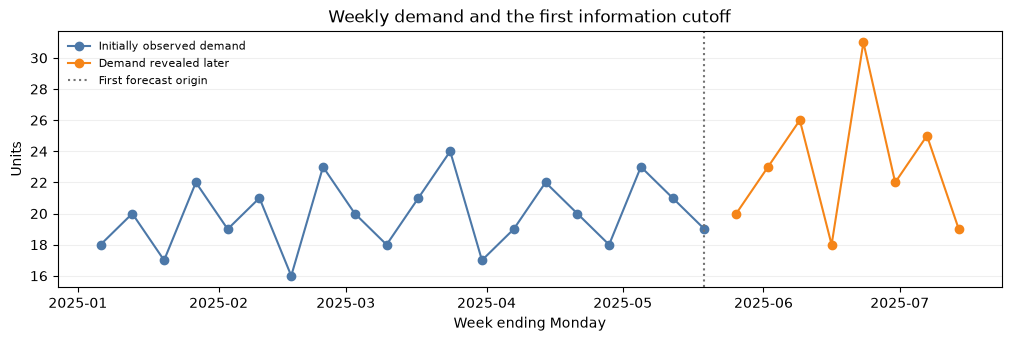

In [4]:
fig, ax = plt.subplots(figsize=(10, 3.3), layout='constrained')
ax.plot(history.date, history.y, marker='o', color='#4C78A8', label='Initially observed demand')
ax.plot(held_out.date, held_out.y, marker='o', color='#F58518', label='Demand revealed later')
ax.axvline(history.date.iloc[-1], color='0.45', linestyle=':', label='First forecast origin')
ax.set(title='Weekly demand and the first information cutoff', ylabel='Units', xlabel='Week ending Monday')
ax.legend(frameon=False, fontsize=8)
ax.grid(axis='y', alpha=.2)
plt.show()


## 2. Forecast only the next week

At each origin, Smooth fits `ES(model='ANN')` to demand observed by that date and returns a **one-step** upper prediction bound. We round the bound up because this product is ordered in whole units. The rounded number is the stock-position target, not automatically the purchase quantity. Smooth's normal-error assumption is illustrative and would need checking on real demand.

We prepare the eight forecast records now so the example is reproducible. Each fit slices history at its own cutoff; the held-out demand for that week is never used to choose its target.

In [5]:
forecast_rows = []
for week_index, week in held_out.iterrows():
    origin = history.date.iloc[-1] if week_index == 0 else held_out.date.iloc[week_index - 1]
    available = series.loc[series.date.le(origin), 'y']
    assert series.loc[series.date.le(origin), 'date'].max() == origin
    assert origin < week.date
    model = ES(model='ANN')
    model.fit(available)
    forecast = model.predict(h=1, interval='prediction', level=probability,
                             side='upper', cumulative=False)
    mean = float(forecast.mean.iloc[0])
    upper = float(forecast.upper.iloc[0, 0])
    assert np.isfinite([mean, upper]).all() and upper >= 0
    forecast_rows.append({
        'week': week_index + 1, 'forecast_origin': origin, 'date': week.date,
        'fit_rows': len(available), 'forecast_mean': mean,
        'upper_90': upper, 'stock_target': int(np.ceil(upper)),
    })
forecasts = pd.DataFrame(forecast_rows)
print(forecasts.to_string(index=False, float_format=lambda value: f'{value:.2f}'))


 week forecast_origin       date  fit_rows  forecast_mean  upper_90  stock_target
    1      2025-05-19 2025-05-26        20          19.90     22.83            23
    2      2025-05-26 2025-06-02        21          19.90     22.75            23
    3      2025-06-02 2025-06-09        22          20.05     22.95            23
    4      2025-06-09 2025-06-16        23          20.30     23.58            24
    5      2025-06-16 2025-06-23        24          20.21     23.46            24
    6      2025-06-23 2025-06-30        25          20.64     24.90            25
    7      2025-06-30 2025-07-07        26          22.06     26.27            27
    8      2025-07-07 2025-07-14        27          22.87     27.05            28


The target table is the handoff between packages. The forecaster supplies the prediction bound; Stockcast checks its declared probability, origin, one-week horizon, frequency, and end date. The observed demand values remain separate until we run the inventory scenario.

In [6]:
opening_stock = pd.DataFrame({'unique_id': [sku], 'on_hand': [4.0]})
opening = InventoryStateDataFrame([sku], max_lead_time=0, allow_backorders=False).initialize_from_observed(
    opening_stock, on_hand_column='on_hand', start_date=history.date.iloc[-1],
)
print('Opening stock position')
print(opening.inventory_position()[['unique_id', 'date', 'on_hand', 'inventory_position']].to_string(index=False))


Opening stock position
unique_id       date  on_hand  inventory_position
 tea_250g 2025-05-19      4.0                 4.0


## 3. Use the periodic order-up-to API

With weekly periods, `lead_time=0` makes an accepted order available before that week's demand. `review_period=1` allows a decision every week, and the protection horizon is `0 + 1 = 1` week. Each week we fit a new target using that week's dated forecast and carry the engine's ending inventory into the next run. This makes the weekly information cutoff visible without introducing a scheduled multiweek replay yet.

In [7]:
order_up_to_rows = []
state = opening
for week in forecasts.itertuples(index=False):
    target = pd.DataFrame({'unique_id': [sku], 'target': [week.stock_target], 'target_end': [week.date]})
    policy = OrderUpToPolicy(lead_time=0, review_period=1, service_level=probability,
                             allow_backorders=False).fit(
        target, target_column='target', target_probability=probability,
        protection_horizon=1, target_source='external_direct',
        forecast_origin=week.forecast_origin, forecast_frequency=frequency,
        target_end_date_column='target_end',
    )
    demand = pd.DataFrame({'unique_id': [sku], 'period': [0], 'date': [week.date],
                           'y': [float(held_out.loc[week.week - 1, 'y'])]})
    starting_position = float(state.inventory_position().inventory_position.iloc[0])
    result = SimulationEngine().run(
        policy, demand, state, n_periods=1, period_frequency=frequency,
        warmup_periods=0, scoring_periods=1, settlement_periods=0,
        order_during_settlement=False, demand_source_name='declared_heldout_weekly_demand',
        random_seed=None,
    )
    event = validate_event_frame(result.to_event_frame()).iloc[0]
    order_up_to_rows.append({
        'date': week.date, 'stock_target': week.stock_target, 'starting_position': starting_position,
        'demand': event.demand, 'ordered': event.order_quantity, 'received': event.received_units,
        'sold': event.fulfilled_units, 'end_on_hand': event.ending_on_hand,
        'lost_sales': event.lost_sales_units,
    })
    state = result.inventory
order_up_to = pd.DataFrame(order_up_to_rows)
print(order_up_to.to_string(index=False, float_format=lambda value: f'{value:.2f}'))


      date  stock_target  starting_position  demand  ordered  received  sold  end_on_hand  lost_sales
2025-05-26            23               4.00   20.00    19.00     19.00 20.00         3.00        0.00
2025-06-02            23               3.00   23.00    20.00     20.00 23.00         0.00        0.00
2025-06-09            23               0.00   26.00    23.00     23.00 23.00         0.00        3.00
2025-06-16            24               0.00   18.00    24.00     24.00 18.00         6.00        0.00
2025-06-23            24               6.00   31.00    18.00     18.00 24.00         0.00        7.00
2025-06-30            25               0.00   22.00    25.00     25.00 22.00         3.00        0.00
2025-07-07            27               3.00   25.00    24.00     24.00 25.00         2.00        0.00
2025-07-14            28               2.00   19.00    26.00     26.00 19.00         9.00        0.00


The first row shows the inventory arithmetic. The policy requests `max(0, target − inventory position)`. The accepted zero-lead order is received before demand, so `starting on-hand + received − sold = ending on-hand`. A 90% forecast quantile does not promise a 90% realized fill rate.

In [8]:
first = order_up_to.iloc[0]
assert np.isclose(first.ordered, max(0, first.stock_target - first.starting_position))
assert np.isclose(first.starting_position + first.received - first.sold, first.end_on_hand)
print(f"First week: target {first.stock_target:.0f} - starting stock {first.starting_position:.0f} "
      f"= order {first.ordered:.0f}; ending stock {first.end_on_hand:.0f}")


First week: target 23 - starting stock 4 = order 19; ending stock 3


## 4. Use one single-order policy per week

`SingleOrderPolicy` permits one purchase in a run. A fresh one-week policy and a fresh run are therefore needed for each subsequent Monday. The same forecast targets, demand, and carried stock make the two API examples directly comparable. `selling_horizon=1` covers that one weekly demand row.

In [9]:
single_order_rows = []
state = opening
for week in forecasts.itertuples(index=False):
    target = pd.DataFrame({'unique_id': [sku], 'target': [week.stock_target], 'target_end': [week.date]})
    policy = SingleOrderPolicy(lead_time=0, selling_horizon=1, service_level=probability,
                                allow_backorders=False).fit(
        target, target_column='target', target_probability=probability,
        target_source='external_direct', forecast_origin=week.forecast_origin,
        forecast_frequency=frequency, target_end_date_column='target_end',
    )
    demand = pd.DataFrame({'unique_id': [sku], 'period': [0], 'date': [week.date],
                           'y': [float(held_out.loc[week.week - 1, 'y'])]})
    result = SimulationEngine().run(
        policy, demand, state, n_periods=1, period_frequency=frequency,
        warmup_periods=0, scoring_periods=1, settlement_periods=0,
        order_during_settlement=False, demand_source_name='declared_heldout_weekly_demand',
        random_seed=None,
    )
    event = validate_event_frame(result.to_event_frame()).iloc[0]
    single_order_rows.append({
        'date': week.date, 'ordered': event.order_quantity, 'received': event.received_units,
        'sold': event.fulfilled_units, 'end_on_hand': event.ending_on_hand,
        'lost_sales': event.lost_sales_units,
    })
    state = result.inventory
single_order = pd.DataFrame(single_order_rows)
comparison = order_up_to[['date', 'ordered', 'received', 'sold', 'end_on_hand', 'lost_sales']].copy()
for column in comparison.columns.drop('date'):
    assert np.allclose(comparison[column], single_order[column])
print('Both APIs produce the same weekly event flows in this one-period setting.')
print(single_order.to_string(index=False, float_format=lambda value: f'{value:.2f}'))


Both APIs produce the same weekly event flows in this one-period setting.
      date  ordered  received  sold  end_on_hand  lost_sales
2025-05-26    19.00     19.00 20.00         3.00        0.00
2025-06-02    20.00     20.00 23.00         0.00        0.00
2025-06-09    23.00     23.00 23.00         0.00        3.00
2025-06-16    24.00     24.00 18.00         6.00        0.00
2025-06-23    18.00     18.00 24.00         0.00        7.00
2025-06-30    25.00     25.00 22.00         3.00        0.00
2025-07-07    24.00     24.00 25.00         2.00        0.00
2025-07-14    26.00     26.00 19.00         9.00        0.00


## 5. Read forecast and inventory together

The upper line in the first panel is the **one-week** forecast bound; the later observed demand can fall above it. The lower panel shows the stock target, actual order, and end-of-week on-hand. Order and receipt coincide here because lead time is zero, but the order is still reduced by stock already available. On June 23, six units remain, so the shop orders 18 toward a target of 24; demand of 31 then causes seven lost sales.

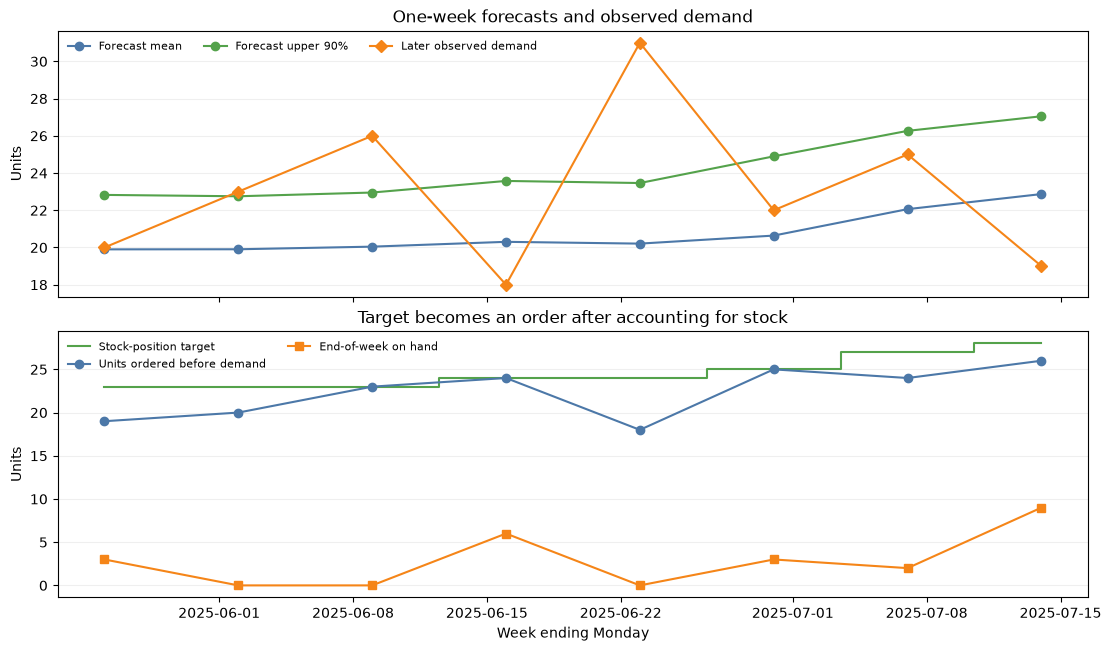

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6.4), sharex=True, layout='constrained')
axes[0].plot(forecasts.date, forecasts.forecast_mean, marker='o', color='#4C78A8', label='Forecast mean')
axes[0].plot(forecasts.date, forecasts.upper_90, marker='o', color='#54A24B', label='Forecast upper 90%')
axes[0].plot(held_out.date, held_out.y, marker='D', color='#F58518', label='Later observed demand')
axes[0].set(title='One-week forecasts and observed demand', ylabel='Units')
axes[0].legend(frameon=False, ncol=3, fontsize=8)
axes[1].step(order_up_to.date, order_up_to.stock_target, where='mid', color='#54A24B', label='Stock-position target')
axes[1].plot(order_up_to.date, order_up_to.ordered, marker='o', color='#4C78A8', label='Units ordered before demand')
axes[1].plot(order_up_to.date, order_up_to.end_on_hand, marker='s', color='#F58518', label='End-of-week on hand')
axes[1].set(title='Target becomes an order after accounting for stock', ylabel='Units', xlabel='Week ending Monday')
axes[1].legend(frameon=False, ncol=2, fontsize=8)
for ax in axes: ax.grid(axis='y', alpha=.2)
plt.show()


## What this establishes

Smooth supplied a dated one-week demand quantile. Both Stockcast policies translated that same target and opening stock into the same weekly order and validated inventory flows. `OrderUpToPolicy` describes a recurring weekly review; `SingleOrderPolicy` describes exactly one purchase in each one-week run. With longer lead times or selling seasons, their coverage contracts differ.

These eight artificial weeks show mechanics and realized outcomes. Choosing and validating the forecasting model, target probability, and product assumptions for a real operation requires more held-out evidence.